# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  float64
 12  previous_loan_defaults_on_file  

None

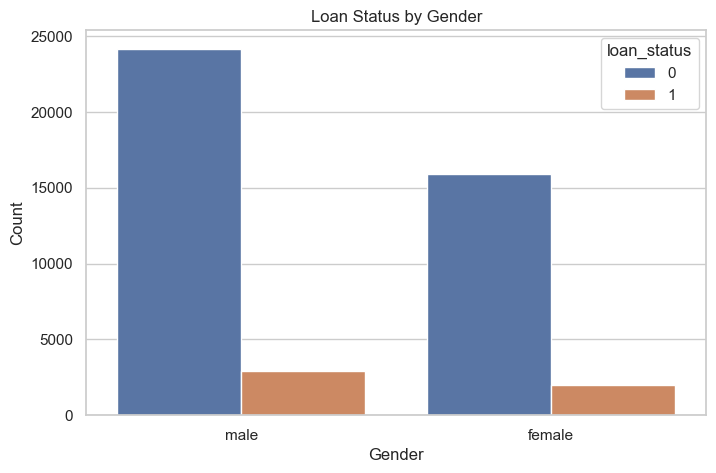

loan_status,0,1
person_gender,,
female,0.889720,0.110280
male,0.892289,0.107711


loan_status,0,1
person_gender,,
female,88.972025,11.027975
male,89.228895,10.771105


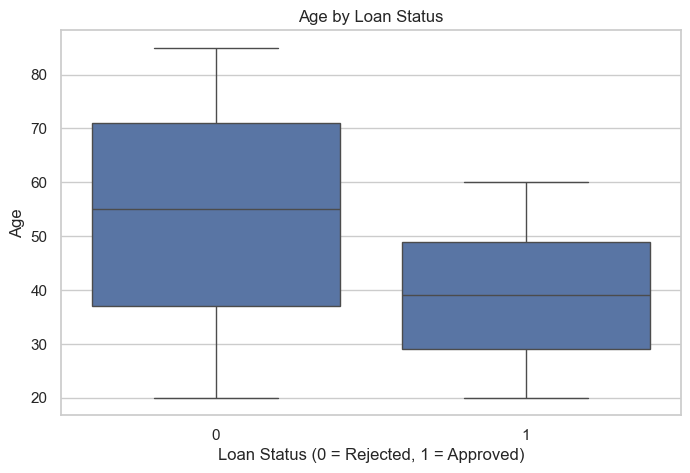

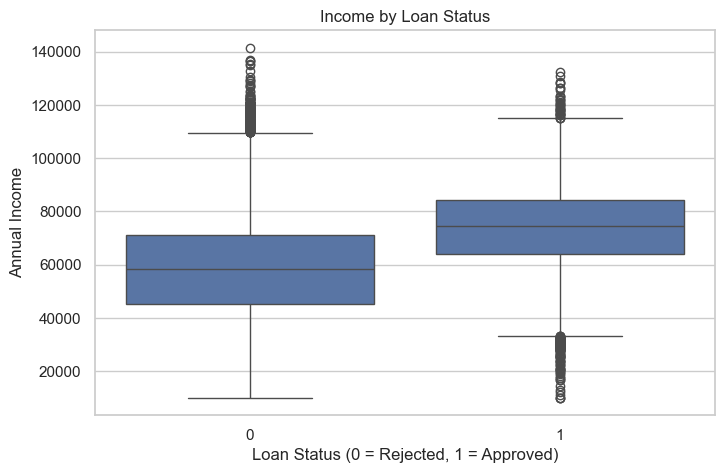

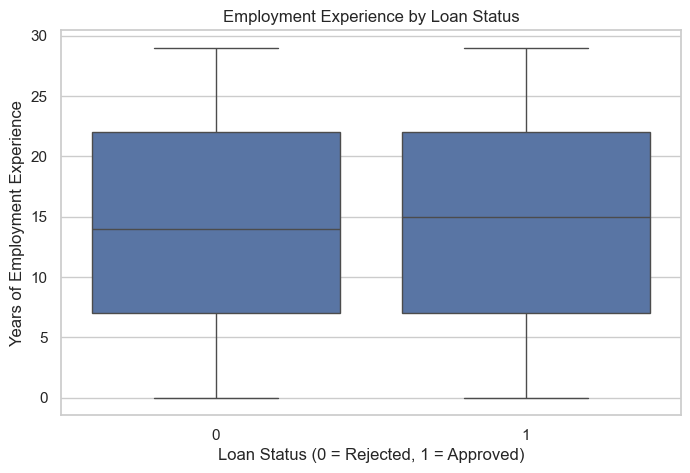

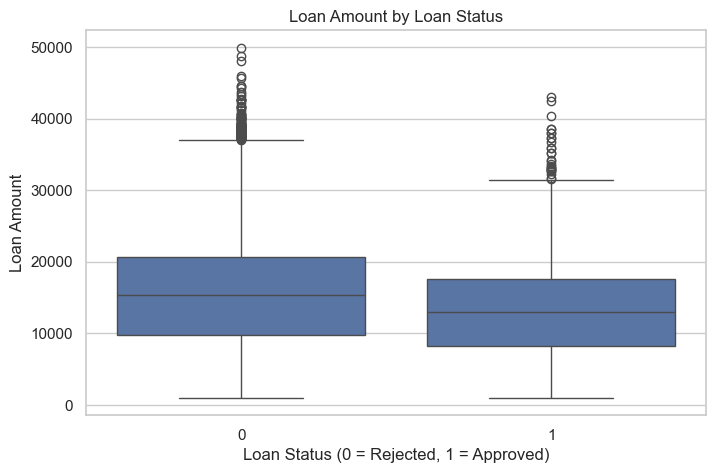

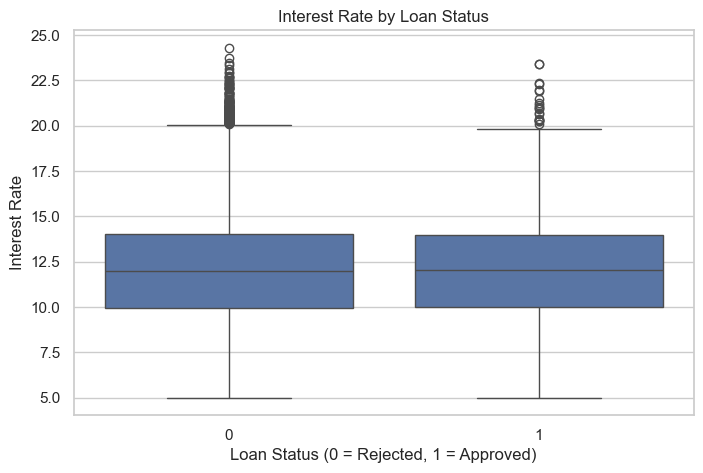

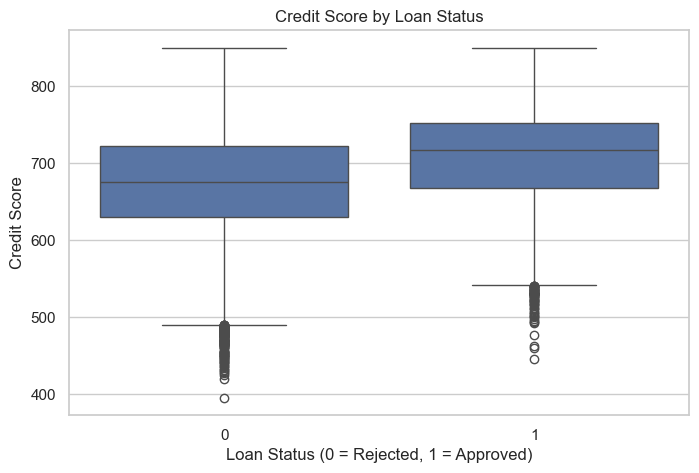

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,credit_score
loan_status,,,,,,
0,55.0,58519.753892,14.0,15308.591209,11.982008,675.642685
1,39.0,74654.580855,15.0,12966.510190,12.018102,717.207593


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("loan_data.csv")

display(df.head())
display(df.info())

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="person_gender", hue="loan_status")
plt.title("Loan Status by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

gender_rate = pd.crosstab(df["person_gender"], df["loan_status"], normalize="index")
display(gender_rate)

approval_by_gender = pd.crosstab(df["person_gender"], df["loan_status"], normalize="index") * 100
display(approval_by_gender)

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="loan_status", y="person_age")
plt.title("Age by Loan Status")
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Age")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="loan_status", y="person_income")
plt.title("Income by Loan Status")
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Annual Income")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="loan_status", y="person_emp_exp")
plt.title("Employment Experience by Loan Status")
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Years of Employment Experience")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="loan_status", y="loan_amnt")
plt.title("Loan Amount by Loan Status")
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Loan Amount")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="loan_status", y="loan_int_rate")
plt.title("Interest Rate by Loan Status")
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Interest Rate")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="loan_status", y="credit_score")
plt.title("Credit Score by Loan Status")
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Credit Score")
plt.show()

summary = df.groupby("loan_status")[[
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "credit_score"
]].median()

display(summary)

## Conclusions

Based on the visualizations, the features that appear to be most related to loan approval are **credit_score**, **person_income**, and **person_age**.

The **credit_score** boxplot shows one of the clearest differences between the two groups. Applicants with approved loans (`loan_status = 1`) have a noticeably higher median credit score than applicants with rejected loans (`loan_status = 0`). The median credit score for rejected applicants is about **675.64**, while the median for approved applicants is about **717.21**. This suggests that higher credit scores are strongly associated with loan approval.

The **person_income** boxplot also shows a clear relationship with loan status. Approved applicants tend to have higher incomes than rejected applicants. The median income for rejected applicants is about **58,519.75**, while the median income for approved applicants is about **74,654.58**. This indicates that income is an important factor in the model’s decision.

The **person_age** boxplot shows another noticeable difference. Approved applicants are generally younger than rejected applicants. The median age for rejected applicants is **55**, while the median age for approved applicants is **39**. Since the two groups are visibly separated, age appears to be related to loan approval.

The feature that seems least related to loan approval is **loan_int_rate**. The boxplots for approved and rejected applicants almost completely overlap, and the medians are nearly identical. The median interest rate for rejected applicants is about **11.98**, while the median for approved applicants is about **12.02**. This suggests that interest rate does not appear to strongly influence approval in this dataset.

Another feature that seems only weakly related is **person_emp_exp**. The employment experience boxplots are very similar, and the medians differ only slightly. The median employment experience is **14 years** for rejected applicants and **15 years** for approved applicants. Since the distributions overlap heavily, employment experience does not appear to be a major driver of loan approval.

The **loan_amnt** boxplot shows some relationship, but it is weaker than credit score, income, and age. Approved applicants tend to request slightly smaller loan amounts. The median loan amount for rejected applicants is about **15,308.59**, while the median for approved applicants is about **12,966.51**. This suggests loan amount may matter somewhat, but not as strongly as the top features.

For **gender**, the countplot and approval rate table show very little difference between males and females. Female applicants have an approval rate of about **11.03%**, while male applicants have an approval rate of about **10.77%**. These percentages are very close, so gender does not appear to strongly influence the model’s decision.

The financial institution **should be more concerned about age than gender** in terms of possible legal trouble. The visualizations suggest that **gender appears largely unrelated** to loan approval, but **age shows a noticeable relationship** with loan status. Because age is a protected characteristic in many legal and ethical discussions about fairness, the fact that younger applicants appear more likely to be approved could raise concerns about possible bias. Based on these visualizations, the institution may need to investigate whether the model is unfairly using age in its decisions.